使用设备: cuda
训练集样本数:60000。测试集样本数:10000
Epoch  1/10, Loss: 0.1313, Test Acc: 0.9852
Epoch  2/10, Loss: 0.0425, Test Acc: 0.9899
Epoch  3/10, Loss: 0.0291, Test Acc: 0.9915
Epoch  4/10, Loss: 0.0210, Test Acc: 0.9908
Epoch  5/10, Loss: 0.0155, Test Acc: 0.9897
Epoch  6/10, Loss: 0.0132, Test Acc: 0.9915
Epoch  7/10, Loss: 0.0111, Test Acc: 0.9903
Epoch  8/10, Loss: 0.0089, Test Acc: 0.9905
Epoch  9/10, Loss: 0.0073, Test Acc: 0.9910
Epoch 10/10, Loss: 0.0075, Test Acc: 0.9885

训练总耗时: 34.17 秒


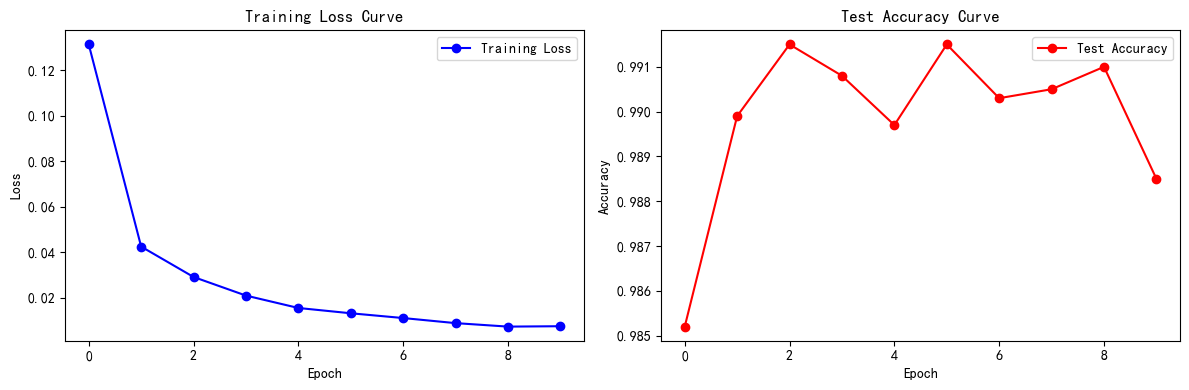

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import time
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")
# 1. 加载MNIST数据:下载,预处理(归一化)、创建DataLoader

# 数据预处理,转为Tensor并标准化为[-1,1]附近。MNIST官方均值0.1307,标准差0.3081
# 先用 DataLoader 把数据加载到 CPU
transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.1307,), (0.3081,))])

train_data = datasets.MNIST(root='./data', train=True, download=False, transform=transform)
test_data = datasets.MNIST(root='./data', train=False, transform=transform)

# 一次性把所有数据转换成 GPU 张量
def preprocess_to_gpu(dataset):
    images = torch.stack([img for img, _ in dataset]).to(device)
    labels = torch.tensor([label for _, label in dataset]).to(device)
    return TensorDataset(images, labels)

train_data_gpu = preprocess_to_gpu(train_data)
test_data_gpu = preprocess_to_gpu(test_data)

train_loader = DataLoader(train_data_gpu, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data_gpu, batch_size=64, shuffle=False)

print(f"训练集样本数:{len(train_data)}。测试集样本数:{len(test_data)}")

# 2. 定义CNN网络:两个卷积层+全连接层,用ReLU激活,最大池化
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1, 1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, 1, 1)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN().to(device)
# 3. 定义损失函数和优化器:交叉熵损失、Adam优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
# 4. 训练循环：10个epoch，记录每个epoch的平均loss和测试准确率。
epochs = 10;train_losses = [];test_accs = []
start_time = time.time()
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    acc = correct / total
    test_accs.append(acc)
    print(f"Epoch {epoch+1:2d}/{epochs}, Loss: {avg_loss:.4f}, Test Acc: {acc:.4f}")

total_time = time.time() - start_time
print(f"\n训练总耗时: {total_time:.2f} 秒")

# 5.画曲线
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, marker='o', color='b', label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(test_accs, marker='o', color='r', label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Test Accuracy Curve')
plt.legend()
plt.tight_layout()
plt.show()

使用设备: cuda
训练集样本数:60000,测试集样本数:10000
训练 Baseline (无正则化)
Baseline - Epoch  1/10, Loss: 0.1422, Test Acc: 0.9847
Baseline - Epoch  2/10, Loss: 0.0428, Test Acc: 0.9897
Baseline - Epoch  3/10, Loss: 0.0283, Test Acc: 0.9876
Baseline - Epoch  4/10, Loss: 0.0211, Test Acc: 0.9877
Baseline - Epoch  5/10, Loss: 0.0167, Test Acc: 0.9900
Baseline - Epoch  6/10, Loss: 0.0120, Test Acc: 0.9899
Baseline - Epoch  7/10, Loss: 0.0105, Test Acc: 0.9894
Baseline - Epoch  8/10, Loss: 0.0075, Test Acc: 0.9906
Baseline - Epoch  9/10, Loss: 0.0082, Test Acc: 0.9921
Baseline - Epoch 10/10, Loss: 0.0069, Test Acc: 0.9903
Baseline训练总耗时:33.88秒

训练 L1 正则化 (λ=0.0001)
L1 - Epoch  1/10, Loss: 0.3288, Test Acc: 0.9749
L1 - Epoch  2/10, Loss: 0.1795, Test Acc: 0.9859
L1 - Epoch  3/10, Loss: 0.1506, Test Acc: 0.9812
L1 - Epoch  4/10, Loss: 0.1351, Test Acc: 0.9856
L1 - Epoch  5/10, Loss: 0.1256, Test Acc: 0.9894
L1 - Epoch  6/10, Loss: 0.1171, Test Acc: 0.9897
L1 - Epoch  7/10, Loss: 0.1122, Test Acc: 0.9881
L1 - Epo

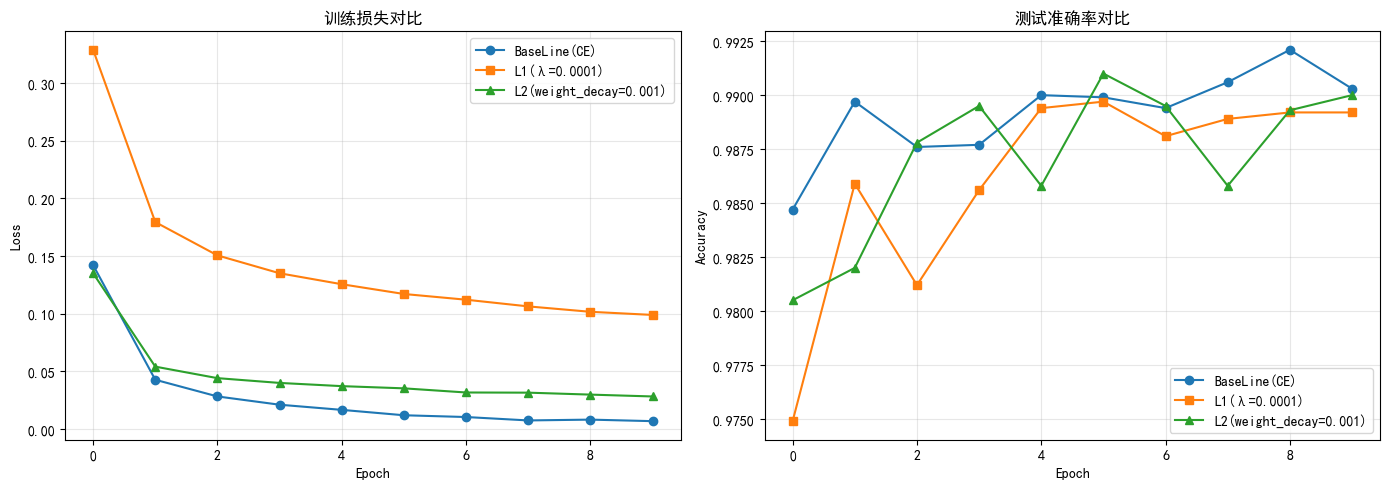

对比完成!


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import time
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" 
# 解决中文显示问题
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
#切换到gpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")
#1.加载数据并转到gpu
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,),(0.3081,))
])
train_data=datasets.MNIST(root='./data',transform=transform,download=True,train=True)
test_data=datasets.MNIST(root='./data',transform=transform,download=True,train=False)
def preprocess_to_gpu(dataset):
    images = torch.stack([img for img, _ in dataset]).to(device)
    labels = torch.tensor([label for _, label in dataset]).to(device)
    return TensorDataset(images, labels)
train_data_gpu=preprocess_to_gpu(train_data)
test_data_gpu=preprocess_to_gpu(test_data)
train_loader=DataLoader(train_data_gpu,64,True)#多少批次
test_loader=DataLoader(test_data_gpu,64,False)
print(f"训练集样本数:{len(train_data)},测试集样本数:{len(test_data)}")
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN,self).__init__()
        self.conv1=nn.Conv2d(1,32,3,1,1)
        self.pool=nn.MaxPool2d(2,2)
        self.conv2=nn.Conv2d(32,64,3,1,1)
        self.fc1=nn.Linear(64*7*7,128)
        self.fc2=nn.Linear(128,10)
        self.relu=nn.ReLU()
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x
def train_and_record(l1_lamda=0,weight_decay=0,version_name="Baseline"):
    """ 通用训练函数,计算损失和准确率 """
    model=SimpleCNN().to(device)
    criterion=nn.CrossEntropyLoss()
    #L2通过weight_decay实现 (weight_decay/2) * ||θ||²。损失函数+这些
    #+λ/2 * ||W||²
    optimizer=optim.Adam(model.parameters(),lr=0.001,weight_decay=weight_decay)
    epochs=10;train_losses=[];test_accs=[]
    start_time=time.time()
    for epoch in range(epochs):
        model.train()
        running_loss=0
        for images,labels in train_loader:
            outputs=model(images)
            loss_ce=criterion(outputs,labels)
            if(l1_lamda>0):#l1正则化
                l1_norm=sum(p.abs().sum() for name,p in model.named_parameters() if 'weight' in name)
                loss=loss_ce+l1_lamda*l1_norm
            else:
                loss=loss_ce
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss+=loss.item()
        avg_loss=running_loss/len(train_loader)
        train_losses.append(avg_loss)
        #测试
        model.eval();correct=0;total=0
        with torch.no_grad():
            for images,labels in test_loader:
                outputs=model(images)
                _,predicted=torch.max(outputs,1)
                total+=labels.size(0)
                correct+=(predicted==labels).sum().item()
        acc=correct/total
        test_accs.append(acc)
        print(f"{version_name} - Epoch {epoch+1:2d}/{epochs}, Loss: {avg_loss:.4f}, Test Acc: {acc:.4f}")
    total_time=time.time()-start_time
    print(f"{version_name}训练总耗时:{total_time:.2f}秒\n")
    return train_losses,test_accs
#训练三种版本
print("="*50)
print("训练 Baseline (无正则化)")
baseline_losses,baseline_accs=train_and_record(0,0,version_name="Baseline")
print("="*50)
print("训练 L1 正则化 (λ=0.0001)")
l1_losses,l1_accs=train_and_record(0.0001,0,version_name="L1")#lamda,weight_decay
print("="*50)
print("训练 L2 正则化 (weight_decay=0.001)")
l2_losses,l2_accs=train_and_record(0,0.001,version_name="L2")
#画对比图
plt.figure(figsize=(14,5))
#损失曲线对比
plt.subplot(1,2,1)
plt.plot(baseline_losses,marker='o',label='BaseLine(CE)',linewidth=1.5)
plt.plot(l1_losses,marker='s',label='L1(λ=0.0001)',linewidth=1.5)
plt.plot(l2_losses,marker='^',label='L2(weight_decay=0.001)',linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('训练损失对比')
plt.legend()
plt.grid(True,alpha=0.3)
#准确率曲线对比
plt.subplot(1,2,2)
plt.plot(baseline_accs,marker='o',label='BaseLine(CE)',linewidth=1.5)
plt.plot(l1_accs,marker='s',label='L1(λ=0.0001)',linewidth=1.5)
plt.plot(l2_accs,marker='^',label='L2(weight_decay=0.001)',linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('测试准确率对比')
plt.legend()
plt.grid(True,alpha=0.3)

plt.tight_layout()
plt.show()

print("对比完成!")

In [9]:
#用MNIST数据集,训练三种传统机器学习模型(逻辑回归,svm,随机森林),对比准确率和耗时
#加载MNIST数据,提取原始像素特征(784维),划分训练/测试集
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import time
#加载MNIST
X,y=fetch_openml('mnist_784',version=1,return_X_y=True,as_frame=False,parser='pandas')#fetch_openml 返回的数据是扁平化的 784 维向量，
X=X/255.0 #归一化到[0,1]
y=y.astype(int)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(f"训练集:{X_train.shape},测试集:{X_test.shape}")#左56000,c测试集14000
#训练三种模型
#逻辑回归
print("-----训练逻辑回归-----")
start=time.time()
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train,y_train)#用训练集训练逻辑回归模型
lr_pred=lr.predict(X_test)#模型在测试集上做预测，得到预测标签
lr_acc=accuracy_score(y_test,lr_pred)
print(f"逻辑回归准确率:{lr_acc:.4f},耗时:{time.time()-start:.2f}秒")
#SVM(用前50000训练样本)
print("-----训练SVM(RBF,5000样本)-----")
X_train_small=X_train[:5000]
y_train_small=y_train[:5000]
start=time.time()
svm=SVC(kernel='rbf',random_state=42)
svm.fit(X_train_small,y_train_small)
svm_pred=svm.predict(X_test)
svm_acc=accuracy_score(y_test,svm_pred)
print(f"SVM准确率:{svm_acc:.4f},耗时:{time.time()-start:.2f}")
#随机森林
print("-----训练随机森林-----")
start=time.time()
rf=RandomForestClassifier(n_estimators=100, n_jobs=-1,random_state=42)#决策树数量n_estimators=100n_jobs=-1
#含义:使用的CPU核心数。解释：-1 表示使用所有可用的 CPU 核心并行训练
rf.fit(X_train,y_train)
rf_pred=rf.predict(X_test)
rf_acc=accuracy_score(y_test,rf_pred)
print(f"随机森林准确率:{rf_acc:.4f},耗时:{time.time()-start:.2f}")

训练集:(56000, 784),测试集:(14000, 784)
-----训练逻辑回归-----
逻辑回归准确率:0.9202,耗时:23.89秒
-----训练SVM(RBF,5000样本)-----
SVM准确率:0.9513,耗时:17.07
-----训练随机森林-----
随机森林准确率:0.9675,耗时:5.28


In [ ]:
import os
from openai import OpenAI
api_key=os.environ.get("Agent_Api_Key")
client=OpenAI(api_key=api_key,base_url="https://apihub.agnes-ai.com/v1")
response=client.chat.completions.create(
    model="agents-2.0-flash",
    messages=[{"role":"user","content":""}]
)

sk-iai3aOapqGUKF6pAPg5sbcuAroH7zkquUrjhAVu9CLzTpMMu
